In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_titles.csv")

In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [21]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [22]:
df.groupby("type")["show_id"].count()

type
Movie      6131
TV Show    2676
Name: show_id, dtype: int64

In [52]:
df_country = df.copy()

df_country = df_country.dropna(subset=["country"])
df_country["country"] = df_country["country"].apply(lambda x: x.split(","))

df_country = df_country.explode("country")
df_country["country"] = df_country["country"].str.strip()

df_country["country"].value_counts().head(5)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Name: count, dtype: int64

In [59]:
df_listed = df.copy()

df_listed = df_listed.dropna(subset=["listed_in"])
df_listed["listed_in"] = df_listed["listed_in"].apply(lambda x: x.split(","))

df_listed = df_listed.explode("listed_in")
df_listed["listed_in"] = df_listed["listed_in"].str.strip()



In [ ]:
df_listed.groupby("listed_in")["show_id"].count().reset_index().sort_values(by="show_id", ascending=False).head(10)df_listed.groupby("listed_in")["show_id"].count().reset_index().sort_values(by="show_id", ascending=False).head(10)df_listed.groupby("listed_in")["show_id"].count().reset_index().sort_values(by="show_id", ascending=False).head(10)

,listed_in,show_id
16,International Movies,2752
12,Dramas,2427
7,Comedies,1674
17,International TV Shows,1351
10,Documentaries,869
0,Action & Adventure,859
34,TV Dramas,763
15,Independent Movies,756
4,Children & Family Movies,641
24,Romantic Movies,616


In [73]:
df_listed["listed_in"].value_counts().head(10).reset_index()

,listed_in,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


In [81]:
release_year_list = df["release_year"].value_counts().reset_index()

In [98]:
release_year_list

,release_year,count
0,2018,1147
1,2017,1032
2,2019,1030
3,2020,953
4,2016,902
...,...,...
69,1959,1
70,1925,1
71,1961,1
72,1947,1


<Axes: xlabel='release_year', ylabel='count'>

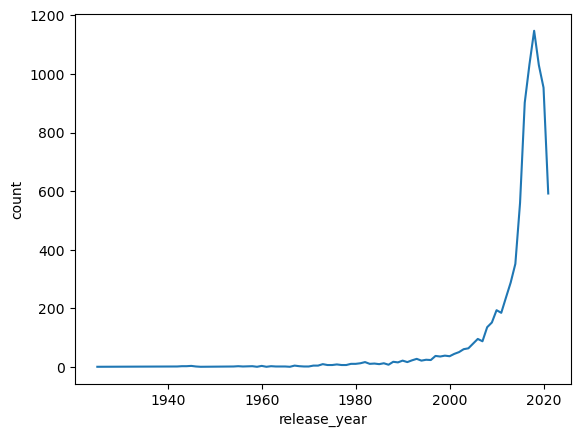

In [97]:
sns.lineplot(data= release_year_list, x="release_year", y="count")

In [101]:
release_year_list = df[["release_year", "type"]].value_counts().reset_index()

In [102]:
release_year_list

,release_year,type,count
0,2017,Movie,767
1,2018,Movie,767
2,2016,Movie,658
3,2019,Movie,633
4,2020,Movie,517
...,...,...,...
114,1963,TV Show,1
115,1972,TV Show,1
116,1966,Movie,1
117,1985,TV Show,1


<Axes: xlabel='release_year', ylabel='count'>

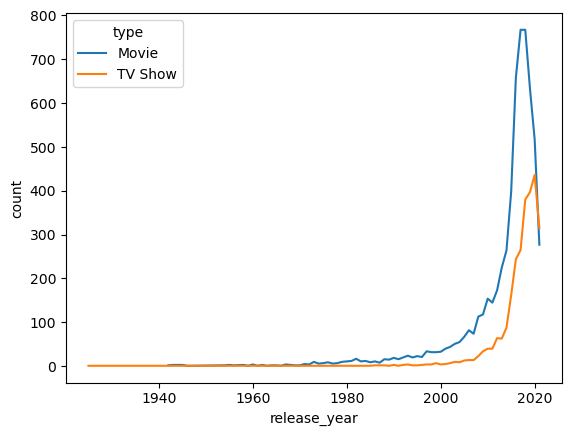

In [103]:
sns.lineplot(data= release_year_list, x="release_year", hue= "type", y="count")

In [118]:
date_list = df[["date_added"]]

In [120]:
type(date_list)

pandas.core.frame.DataFrame

In [124]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")